# AthenaK dust drag-solver tests

This notebook is a concise, executable companion to
`Tier-S_drag_solver_implementation_and_validation_report_v3.pdf`. It records the
frozen Tier-S results from 2026-07-21 at AthenaK revision `a3814802`: resolved and
strong-stiff full-state convergence, algebra/conservation gates, and normalized
Mac MPI-8 and WSL2 CUDA cost.

> **Bottom line.** In the tested resolved high-loading regime, `dc1` recovers the
> complete method's nominal second-order temporal convergence at
> $1.19$-$1.46\times$ the `local` Tier-S cost. When drag remains unresolved,
> even a strictly converged `pcg` stage approaches first-order full-state
> refinement; the limitation is then in the outer IMEX/particle update, not the
> linear solve.

| Result | Frozen v3 value |
|---|---:|
| DC1 cost relative to local | $1.19$-$1.46\times$ |
| finest resolved DC1 order, all gas primitives | 1.9012 |
| finest resolved DC1 order, particle velocity | 1.9279 |
| finest strong-stiff PCG order, all gas primitives | 0.9987 |
| maximum recomputed strong-stiff PCG residual | $1.55\times10^{-12}$ |

`dc2` and the later GH200 reduction-fusion performance measurements postdate the frozen
v3 report and are intentionally not mixed into the plots below.


## 1. Solver paths being compared

For each velocity component, the gas mesh velocity is the global unknown:

$$
A=\operatorname{diag}(\rho_g)
+G^T\operatorname{diag}\left(\frac{m_jc_j}{V}\right)G,
\qquad
b=p_g+G^T\operatorname{diag}\left(\frac{m_jc_j}{V}\right)v_j,
$$

$$
c_j=\frac{\gamma\Delta t}{t_{s,j}+\gamma\Delta t}.
$$

Matching particle-mesh weights in $G$ and $G^T$ make $A$ symmetric positive definite
for positive gas density on the supported periodic uniform mesh. Each particle has its
own $c_j$, so multiple species change coefficients and conditioning but not the number
of mesh unknowns.

| Mode | Role in the v3 tests |
|---|---|
| `local` | inexpensive conservative cell-local baseline and preconditioner |
| `dc1` | local candidate plus one fixed preconditioned defect correction |
| `pcg` | strict true-residual converged matrix-free reference solve |
| `adaptive` | certify DC1, otherwise continue to the same strict PCG solve |

The diagnostic-only `applya` path is not a physical production solver and is omitted
from the result plots.


## 2. Frozen Tier-S benchmark set

Tier-S is a small, deterministic, fixed-cycle regression tier. It is designed for
routine cross-backend correctness and relative-cost comparisons, not as a
production-scale science benchmark.

| Case | Frozen configuration | Cycles |
|---|---|---:|
| damping | $32^2$, $8^2$ blocks, PPC 3, three stopping times | 2000 |
| linA | downscaled $32^2$ streaming-instability mode, $8^2$ blocks | 2000 |
| ordinary clump | $64^2$, PPC 16, 65,536 BA2-seeded particles, $t_s=0.1$, $\Delta t=0.01$ | 500 |
| stiff clump | same realization, $t_s=10^{-3}$, $\Delta t=0.01$ | 500 |
| migration | same cloud, common $v_x=5$, zero slip, repeated block/rank/domain crossing | 500 |

The clump pgen deterministically selects 65,536 particles from
`BA2.prtcl_all.00121.part.vtk`; the initial local dust loading peaks near 14.7.


## 3. How to run the frozen cost matrix

Two executables are required because AthenaK selects a custom pgen at compile time:

```bash
# General damping and linA cases
cmake -S athenak -B /path/to/build-general \
  -DCMAKE_BUILD_TYPE=Release -DPROBLEM=built_in_pgens
cmake --build /path/to/build-general -j

# Snapshot-seeded ordinary, stiff, and migration clumps
cmake -S athenak -B /path/to/build-clump \
  -DCMAKE_BUILD_TYPE=Release -DPROBLEM=tests/dust_snapshot_clump
cmake --build /path/to/build-clump -j
```

Add the normal MPI or Kokkos CUDA configure options for the target backend. Then run
the checked-in harness from the directory containing both repositories:

```bash
athenak_dust_tests/scripts/run_tier_s_drag_solver_bench.sh single-gpu \
  /path/to/build-general/src/athena \
  /path/to/build-clump/src/athena \
  athenak_dust_tests/inputs \
  /path/to/BA2.prtcl_all.00121.part.vtk \
  /path/to/tier_s_results
```

Use `mac-mpi8` instead of `single-gpu` for the MacPorts MPI-8 path. The runner executes
three repetitions of every case/mode pair and writes only below the explicit result
directory. Analyze the logs with:

```bash
python athenak_dust_tests/scripts/analyze_tier_s_drag_solver_bench.py \
  --root /path/to/tier_s_results \
  --platform "single GPU"
```

The analyzer rejects missing logs, wrong solver modes, wrong implicit-stage counts, or
runs that stop before the frozen cycle count.


## 4. Paired full-state temporal ladders

The decisive accuracy test used the same moving particles, TSC transfer, $64^2$ mesh,
65,536 BA2-seeded particles, initial slip $(0.1,0,0)$, and final time $T=0.04$.

| Quantity | Resolved ladder | Strong-stiff ladder |
|---|---:|---:|
| stopping time | $t_s=0.1$ | $t_s=10^{-5}$ |
| timestep levels | $2.5\times10^{-3}$ through $1.5625\times10^{-4}$ | same five values |
| $\Delta t/t_s$ | 0.025 through 0.0015625 | 250 through 15.625 |
| modes | `local`, `dc1`, strict `pcg` | `local`, `dc1`, strict `pcg` |
| $\gamma$ in the plots below | $1+1/\sqrt{2}$ | $1+1/\sqrt{2}$ |

Every run wrote the initial and final gas `hydro_w` VTK state and particle `prtcl_all`
PVTK state. At common final time, gas density and all three velocities were compared
cell by cell. Particles were sorted by persistent tag before comparing positions and
velocities; periodic position differences used the minimum image.

For a scalar component,

$$
D_q(h,h/2)=\left[\frac{1}{N}\sum_i
\left(q_i^{(h)}-q_i^{(h/2)}\right)^2\right]^{1/2},
\qquad
p(h)=\log_2\frac{D(h,h/2)}{D(h/2,h/4)}.
$$

Five timestep levels give four pairwise differences and three observed orders. These
full-state ladders were run separately from the fixed-cycle cost harness using a
dedicated clump input with VTK/PVTK output. The one-command full-state ladder driver
and tag-aware analyzer used for v3 remain in the archived GH200 run tree rather than
this repository; the exact parameter matrix and measured results are preserved here.


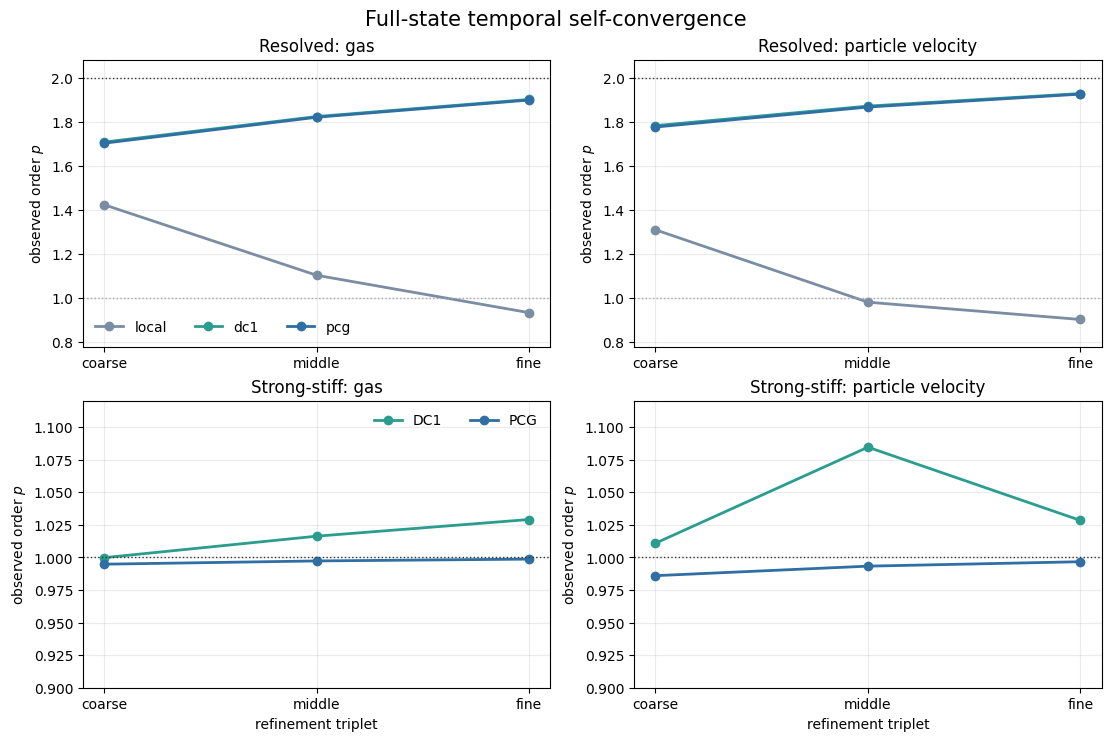

In [1]:
import numpy as np
import matplotlib.pyplot as plt

colors = {'local': '#7a8da3', 'dc1': '#2a9d8f', 'pcg': '#2f6fa3'}
triplets = np.arange(3)
triplet_labels = ('coarse', 'middle', 'fine')

resolved = {
    'gas': {
        'local': (1.4236, 1.1038, 0.9342),
        'dc1': (1.7076, 1.8236, 1.9012),
        'pcg': (1.7027, 1.8204, 1.8984),
    },
    'particle velocity': {
        'local': (1.3099, 0.9817, 0.9033),
        'dc1': (1.7823, 1.8710, 1.9279),
        'pcg': (1.7760, 1.8666, 1.9252),
    },
}
stiff = {
    'gas': {
        'dc1': (0.9998, 1.0163, 1.0291),
        'pcg': (0.9948, 0.9973, 0.9987),
    },
    'particle velocity': {
        'dc1': (1.0109, 1.0846, 1.0284),
        'pcg': (0.9860, 0.9933, 0.9967),
    },
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7.3), constrained_layout=True)
for column, quantity in enumerate(('gas', 'particle velocity')):
    axis = axes[0, column]
    for mode, values in resolved[quantity].items():
        axis.plot(triplets, values, marker='o', linewidth=2, color=colors[mode], label=mode)
    axis.axhline(2.0, color='0.2', linestyle=':', linewidth=1)
    axis.axhline(1.0, color='0.65', linestyle=':', linewidth=1)
    axis.set_ylim(0.78, 2.08)
    axis.set_title(f'Resolved: {quantity}')
    axis.set_xticks(triplets, triplet_labels)
    axis.set_ylabel('observed order $p$')
    axis.grid(alpha=0.25)

    axis = axes[1, column]
    for mode, values in stiff[quantity].items():
        axis.plot(triplets, values, marker='o', linewidth=2, color=colors[mode], label=mode.upper())
    axis.axhline(1.0, color='0.2', linestyle=':', linewidth=1)
    axis.set_ylim(0.90, 1.12)
    axis.set_title(f'Strong-stiff: {quantity}')
    axis.set_xticks(triplets, triplet_labels)
    axis.set_xlabel('refinement triplet')
    axis.set_ylabel('observed order $p$')
    axis.grid(alpha=0.25)

axes[0, 0].legend(frameon=False, ncol=3)
axes[1, 0].legend(frameon=False, ncol=2)
fig.suptitle('Full-state temporal self-convergence', fontsize=15)
plt.show()


The resolved plots separate the methods cleanly: `dc1` and strict `pcg`
approach $p=2$ together, whereas `local` approaches $p=1$. In the strong-stiff ladder,
strict PCG has recomputed true residuals near $10^{-12}$ but still approaches $p=1$.
More inner iterations therefore cannot restore uniform second order to the present
outer method.

With `gamma_switch=true`, the strong-stiff PCG error coefficient becomes much smaller,
but the finest orders still approach 1.0277 for all gas primitives and 1.0178 for
particle velocity. This is improved large-step stiff asymptotic behavior, not
conventional $O(\Delta t^2)$ refinement while $\Delta t\gg t_s$.


## 5. Algebra, conservation, and multi-species gates

| Check | Worst measured v3 result |
|---|---:|
| matrix-free $Ax$ versus dense $Ax$, 400 randomized systems | $4.73\times10^{-16}$ relative |
| strict PCG stage versus dense solution | $1.17\times10^{-13}$ relative state error |
| normalized total momentum drift in randomized ensemble | $9.43\times10^{-16}$ |
| adaptive decisions | 101 fast accepts, 299 fallbacks, zero false accepts |
| strict-PCG iterations in randomized ensemble | min/median/p95/max = 1/2/3/3 |
| resolved full-state momentum drift | $5.55\times10^{-16}$ DC1; $5.00\times10^{-16}$ PCG |

The two-species clump with $t_s=(10^{-3},10^{-1})$ required 23-26 PCG iterations;
`pcg` and `adaptive` histories agreed to $1.18\times10^{-13}$ and total momentum drift
was $5.80\times10^{-14}$. A three-species uniform damping test had total momentum
error $2.95\times10^{-17}$ for every solver mode.

These checks establish the matrix-free operator, action-reaction conservation, and
multi-species formulation. They do not by themselves establish the temporal order of
the moving full state; that is why the paired ladders above are necessary.


## 6. Frozen Tier-S performance

Every mode/case combination was run three times. Each plotted value is the median wall
time divided by the same-build, same-case `local` median. These are within-platform
solver-cost comparisons; the small CUDA cases are partly dominated by launch and
synchronization overhead and must not be used as a CPU-versus-GPU comparison.


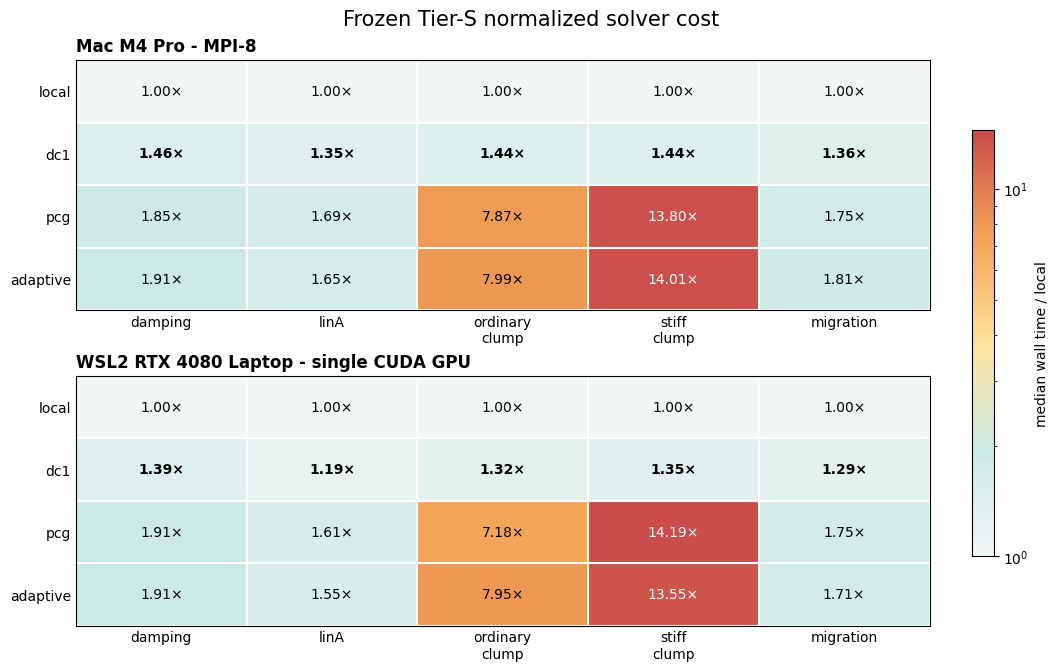

In [2]:
from matplotlib.colors import LinearSegmentedColormap, LogNorm

cases = ('damping', 'linA', 'ordinary\nclump', 'stiff\nclump', 'migration')
modes = ('local', 'dc1', 'pcg', 'adaptive')
platforms = {
    'Mac M4 Pro - MPI-8': np.array([
        [1.00, 1.00, 1.00, 1.00, 1.00],
        [1.46, 1.35, 1.44, 1.44, 1.36],
        [1.85, 1.69, 7.87, 13.80, 1.75],
        [1.91, 1.65, 7.99, 14.01, 1.81],
    ]),
    'WSL2 RTX 4080 Laptop - single CUDA GPU': np.array([
        [1.00, 1.00, 1.00, 1.00, 1.00],
        [1.39, 1.19, 1.32, 1.35, 1.29],
        [1.91, 1.61, 7.18, 14.19, 1.75],
        [1.91, 1.55, 7.95, 13.55, 1.71],
    ]),
}
cmap = LinearSegmentedColormap.from_list(
    'tier_s_cost', ('#f2f6f7', '#cce9e3', '#fee39b', '#f3a354', '#ca4b4b')
)
norm = LogNorm(vmin=1.0, vmax=14.5)

fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.6), constrained_layout=True)
for axis, (title, values) in zip(axes, platforms.items()):
    image = axis.imshow(values, cmap=cmap, norm=norm, aspect='auto')
    axis.set_title(title, loc='left', fontweight='bold')
    axis.set_xticks(np.arange(len(cases)), cases)
    axis.set_yticks(np.arange(len(modes)), modes)
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            color = 'white' if value >= 10 else 'black'
            axis.text(column, row, f'{value:.2f}×', ha='center', va='center',
                      color=color, fontweight='bold' if row == 1 else 'normal')
    axis.tick_params(length=0)
    axis.set_xticks(np.arange(-0.5, len(cases), 1), minor=True)
    axis.set_yticks(np.arange(-0.5, len(modes), 1), minor=True)
    axis.grid(which='minor', color='white', linewidth=1.5)
    axis.tick_params(which='minor', bottom=False, left=False)

fig.colorbar(image, ax=axes, label='median wall time / local', fraction=0.025)
fig.suptitle('Frozen Tier-S normalized solver cost', fontsize=15)
plt.show()


## 7. Interpretation

- `dc1` remains within $1.19$-$1.46\times$ `local` across the frozen matrix and is the
  tested resolved-regime accuracy/cost sweet spot.
- Strict `pcg` is a valuable invariant oracle and certified coupled-stage solve. In
  persistent clumps its 14-32 iterations per stage raise cost to roughly
  $8\times$-$14\times$ `local`.
- `adaptive` is cost-effective only when smooth cases fast-accept DC1. It gives no cost
  advantage when persistent clumps or nonlinear saturation force fallback every stage.
- A converged PCG stage prevents uncontrolled drag feedback and keeps the strong-stiff,
  high-loading state bounded and conservative, but it does not cure outer-method stiff
  order reduction.

The defensible v3 claim is therefore:

> For fixed positive stopping time in the resolved-drag regime, DC1 is observed to
> recover the nominal second-order temporal convergence of the complete moving-TSC
> gas-particle method in the tested high-loading BA2 clump. This accuracy is not
> uniform with respect to stiffness: when the relaxation remains unresolved, the
> present outer method approaches first-order full-state refinement even with a
> strictly converged PCG stage.
